# Import packages

In [1]:
# %pip install sodapy
# %pip install geopandas
# %pip install ipywidgets
# %pip install tqdm

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from sodapy import Socrata
import requests

import tqdm
import json
import os
import shapely
import folium

env = os.environ

# Getting the data

## Getting Bus Speed Data

### Scraping the data

In [3]:
# Settings
api_key = env.get("API_KEY")
app_token = env.get("APP_TOKEN")
secret_key = env.get("SECRET_KEY")

DATASET_ID = "kufs-yh3x"  # for 2025 # for 2024 "58t6-89vi"
limit = 100000
offset = 0

Filter = 'Manhattan'
client = Socrata("data.ny.gov", app_token = app_token)

In [4]:
# getting the data with api call
# all_results = []

# while True:
#     batch = client.get(
#         DATASET_ID,
#         where = "Borough = 'Manhattan'",
#         limit=limit,
#         offset=offset
#     )
#     if not batch:
#         break
#     all_results.extend(batch)
#     print(f"Downloaded {len(batch)} records (offset {offset})")
#     offset += limit

# data_df = pd.DataFrame(all_results)

## saving the data
# data_df.to_csv("Manhattan_Bus_data_23-24.csv")

### Loading the saved data

In [5]:
# loading the data for 2025
speed_data_25 = pd.read_csv("MTA_Bus_Route_Segment_Speeds__Beginning_2025_20251028.csv")

In [6]:
# loading the data for 2023 - 24
speed_data_23_24 = pd.read_csv("MTA_Bus_Route_Segment_Speeds__2023_-_2024_20251029.csv")

## Getting Stop Data

In [7]:
# extracted using Github Project
stop_data = pd.read_csv("manhattan_stops_flat.csv")

# Cleaning the data

## Cleaning Bus Speed Data

I combined the two datasets for 2023-24 and 2025 into one dataframe called data_df. I also dropped unnecessary columns like Borough and Georeference columns.

In [8]:
data_df = pd.concat([speed_data_25, speed_data_23_24], axis = 0)
data_df = data_df.drop(["Timepoint Stop Georeference", "Next Timepoint Stop Georeference", "Borough"], axis = 1)

I then replaced the column headers with lowercase versions and underscores instead of spaces to match it with the stop data more easily.

In [9]:
data_df.columns = data_df.columns.str.lower()
data_df.columns = data_df.columns.str.replace(" ", "_")

I continued by adding a "direction_id" column which is either 0 if the direction is N or S or 1 if the direction is E or W. This will allow me to match it with the stop data later.

In [10]:
# add a direction column (0 and 1) (N, S = 0 and E, W = 1) - to match it with stop data
data_df["direction_id"] = data_df["direction"].apply(lambda x: 0 if x == "N" or x == "E" else 1)
data_df = data_df.drop("direction", axis = 1)

## Cleaning Stops data

To be able to match the stop data with the bus speed data, I added a new route_id column by extracting the last characters behind the "_" from the route_id column. I also increased the stop_order column by 1 to match the stop order in the bus speed data.

In [11]:
# extracting the same route name
stop_data["route_id_new"] = stop_data["route_id"].apply(lambda x: x[x.find("_") +1:])

# adding 1 to stop order to match with speed data
stop_data["stop_order_new"] = stop_data["stop_order"] + 1

# Plotting the data

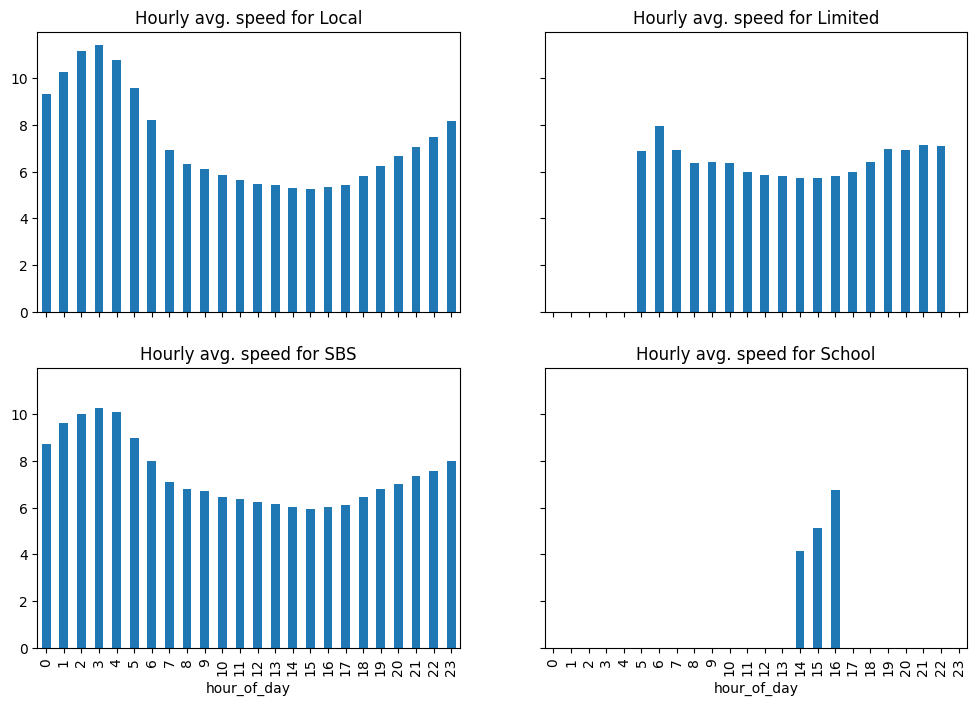

In [12]:
figs, axes = plt.subplots(2,2, figsize = (12,8), sharex = True, sharey = True)

options = list(data_df["route_type"].unique())
hours = list(range(24))

for i, ax in enumerate(axes.flatten()):
    condition = options[i]
    subset = data_df[data_df["route_type"] == condition]
    subset.groupby(["hour_of_day"])["average_road_speed"].mean().reindex(hours).plot(kind = "bar", ax = ax)
    ax.set_title(f"Hourly avg. speed for {condition}")


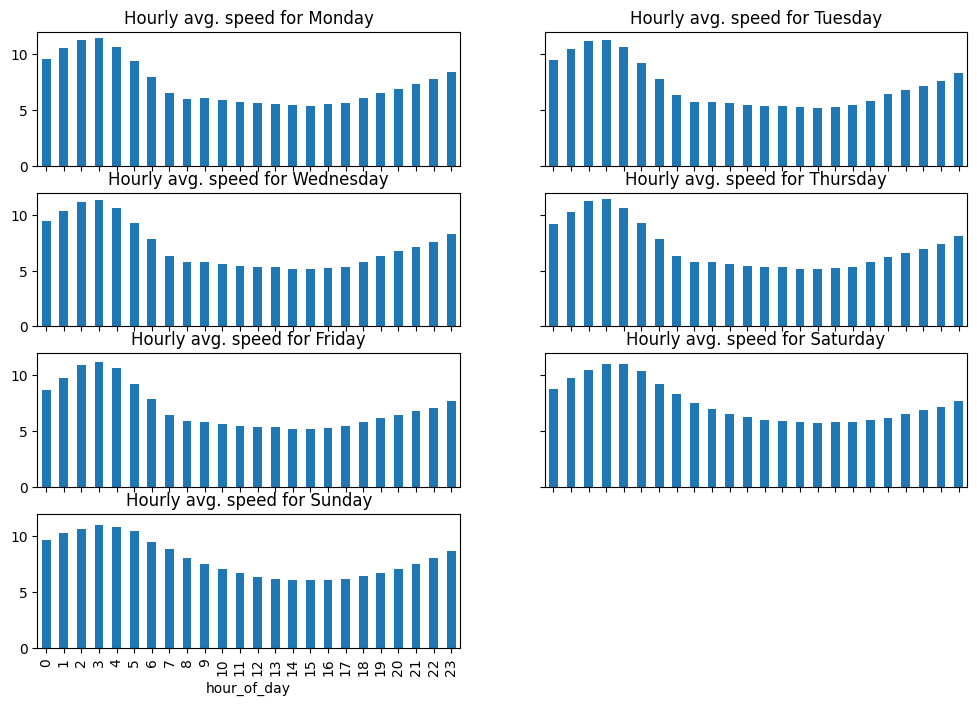

In [13]:
figs, axes = plt.subplots(4,2, figsize = (12,8), sharex = True, sharey = True)

options = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hours = list(range(24))

for i, ax in enumerate(axes.flatten()):
    if i < len(options):
        condition = options[i]
        subset = data_df[data_df["day_of_week"] == condition]
        subset.groupby(["hour_of_day"])["average_road_speed"].mean().reindex(hours).plot(kind = "bar", ax = ax)
        ax.set_title(f"Hourly avg. speed for {condition}")
    else:
        ax.set_visible(False)
        continue


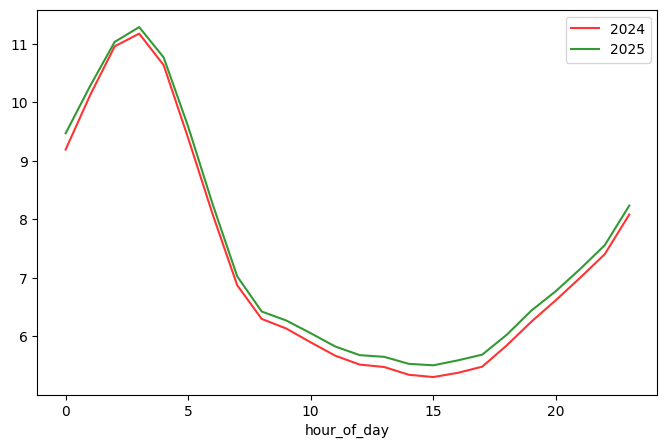

In [14]:
figs, axes = plt.subplots(figsize = (8,5), sharex = True, sharey = True)

options = [2024, 2025]
colors = ["r", "g"]
hours = list(range(24))

for i in range(2):
    condition = options[i]
    subset = data_df[(data_df["year"] == condition)]
    subset.groupby(["hour_of_day"])["average_road_speed"].mean().reindex(hours).plot(kind = "line", alpha = 0.8, color = colors[i], label = condition)
    plt.legend()


In [15]:
average_speed_25 = data_df[(data_df["year"] == 2025)].groupby(["hour_of_day"])["average_road_speed"].mean().reindex(hours)
average_speed_24 = data_df[(data_df["year"] == 2024)].groupby(["hour_of_day"])["average_road_speed"].mean().reindex(hours)
average_speed_23 = data_df[(data_df["year"] == 2023)].groupby(["hour_of_day"])["average_road_speed"].mean().reindex(hours)

In [16]:
average_speed_comparison = pd.concat([average_speed_23, average_speed_24, average_speed_25], axis = 1)
average_speed_comparison.columns = ["2023", "2024", "2025"]
average_speed_comparison["diff_24_25"] = (average_speed_comparison["2025"] - average_speed_comparison["2024"]) / average_speed_comparison["2024"]
average_speed_comparison["diff_23_25"] = (average_speed_comparison["2025"] - average_speed_comparison["2023"]) / average_speed_comparison["2023"]

## Looking at change in average speed per bus per year vs. 2023

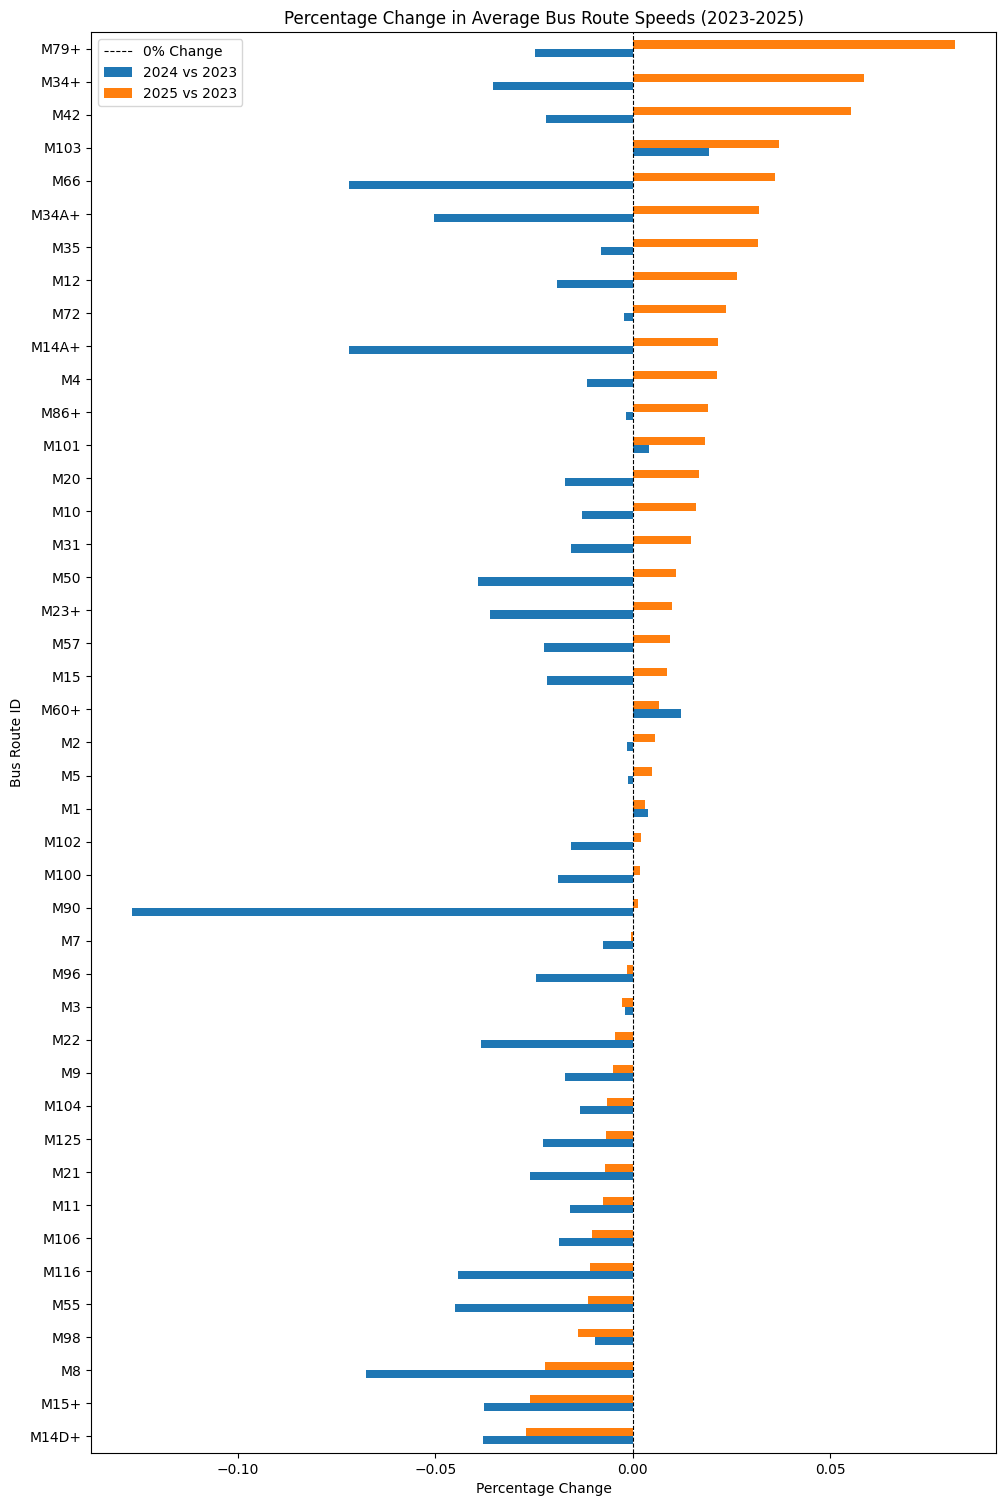

In [17]:
bus_speed = data_df.groupby(["year", "route_id"])["average_road_speed"].mean().unstack(level=0)
# bus_speed["25_fastest"] = ((bus_speed[2025] > bus_speed[2024]) & (bus_speed[2025] > bus_speed[2023])).astype(int)
# bus_speed["24_fastest"] = ((bus_speed[2024] > bus_speed[2025]) & (bus_speed[2024] > bus_speed[2023])).astype(int)

bus_speed["25_perc"] = (bus_speed[2025] - bus_speed[2023]) / bus_speed[2023].fillna(-np.inf)
bus_speed["24_perc"] = (bus_speed[2024] - bus_speed[2023]) / bus_speed[2023].fillna(-np.inf)

bus_speed["25_faster"] = (bus_speed[2025] - bus_speed[2023]) / bus_speed[2023].fillna(-np.inf)
bus_speed = bus_speed.sort_values(by= ["25_faster"])

# Plotting
order = bus_speed.index.tolist()
bus_speed.loc[order, ["24_perc", "25_perc"]].plot(kind="barh", figsize=(10,15), legend=True)
plt.title("Percentage Change in Average Bus Route Speeds (2023-2025)")
plt.xlabel("Percentage Change")
plt.ylabel("Bus Route ID")
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(["0% Change", "2024 vs 2023", "2025 vs 2023"])
plt.tight_layout(pad= 0.5)
plt.show()

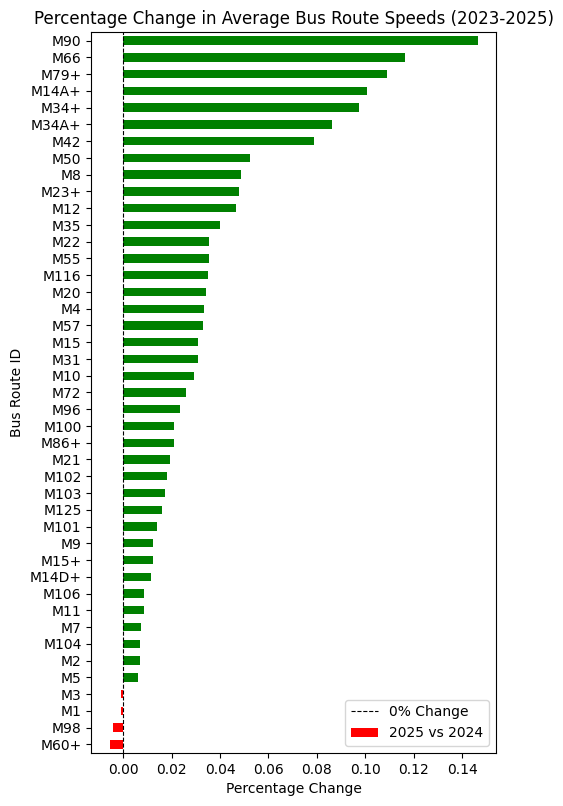

In [18]:
bus_speed["25_perc_24"] = (bus_speed[2025] - bus_speed[2024]) / bus_speed[2024].fillna(-np.inf)
bus_speed = bus_speed.sort_values(by= ["25_perc_24"])
colors_speed = np.where(bus_speed["25_perc_24"] >= 0, 'g', 'r')

# Plotting
order = bus_speed.index.tolist()
bus_speed["25_perc_24"].plot(kind="barh", figsize=(5,8), color=colors_speed)
plt.title("Percentage Change in Average Bus Route Speeds (2023-2025)")
plt.xlabel("Percentage Change")
plt.ylabel("Bus Route ID")
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(["0% Change", "2025 vs 2024"])
plt.tight_layout(pad= 0.5)
plt.show()

# Looking at buses in CBD only

/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_9493/2008429057.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_bus_routes_in_CBD["weekday"] = data_bus_routes_in_CBD["day_of_week"].apply(lambda x: 1 if x in ["Saturday", "Sunday"] else 0)


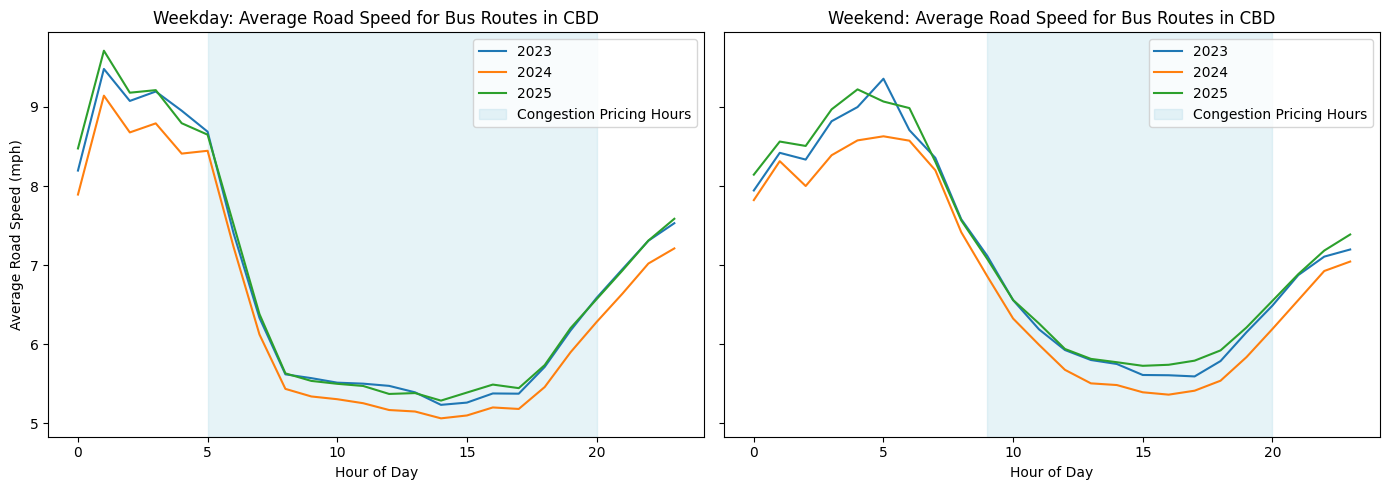

In [19]:
cbd_bus_routes = pd.read_csv("MTA_Central_Business_District_Bus_Routes_20251101.csv")
bus_routes_in_CBD = cbd_bus_routes[cbd_bus_routes["CBD Relation"] == "In CBD"]
data_bus_routes_in_CBD = data_df[data_df["route_id"].isin(bus_routes_in_CBD["Route ID"])]
data_bus_routes_in_CBD["weekday"] = data_bus_routes_in_CBD["day_of_week"].apply(lambda x: 1 if x in ["Saturday", "Sunday"] else 0)

average_speed_bus_routes_in_CBD_weekday = data_bus_routes_in_CBD[data_bus_routes_in_CBD["weekday"] == 0].groupby(["year", "hour_of_day"])["average_road_speed"].mean().unstack(level=0)
average_speed_bus_routes_in_CBD_weekend = data_bus_routes_in_CBD[data_bus_routes_in_CBD["weekday"] == 1].groupby(["year", "hour_of_day"])["average_road_speed"].mean().unstack(level=0)

# average_speed_cbd_weekday = average_speed_bus_routes_in_CBD_weekday.groupby(["year", "day_of_week", "hour_of_day"])["average_road_speed"].mean().unstack(level=0)
# average_speed_cbd_weekend = average_speed_bus_routes_in_CBD_weekend.groupby(["year", "day_of_week", "hour_of_day"])["average_road_speed"].mean().unstack(level=0)

# average_speed_bus_routes_in_CBD_weekday.plot(kind = "line", figsize = (10,6))

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# Weekday plot
average_speed_bus_routes_in_CBD_weekday.reindex(hours).plot(kind="line", ax=axes[0])
axes[0].set_title("Weekday: Average Road Speed for Bus Routes in CBD")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Road Speed (mph)")
axes[0].axvspan(5, 20, color='lightblue', alpha=0.3, label="Congestion Pricing Hours")
axes[0].legend(loc="upper right")

# Weekend plot
average_speed_bus_routes_in_CBD_weekend.reindex(hours).plot(kind="line", ax=axes[1])
axes[1].set_title("Weekend: Average Road Speed for Bus Routes in CBD")
axes[1].set_xlabel("Hour of Day")
axes[1].axvspan(9, 20, color='lightblue', alpha=0.3, label="Congestion Pricing Hours")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

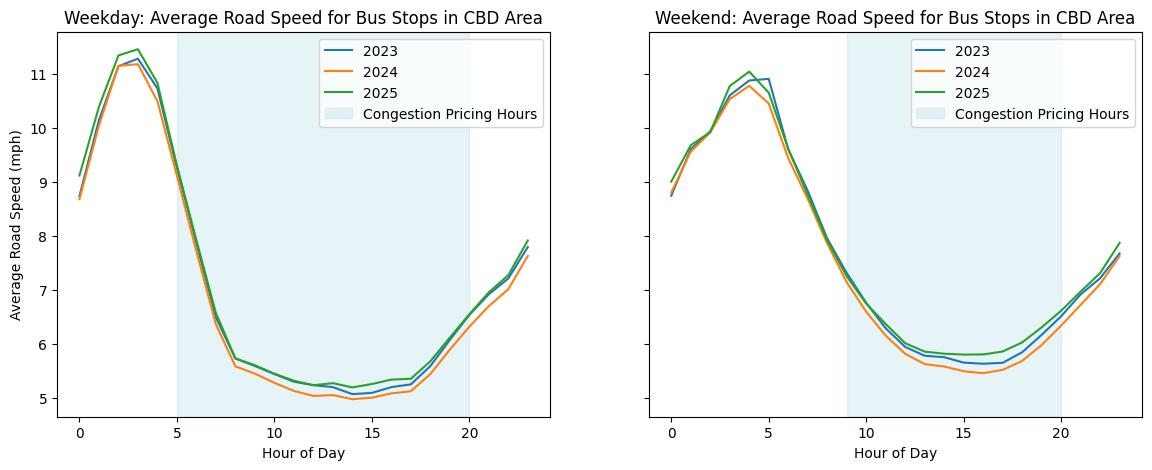

In [52]:
cbd_area = gpd.read_file("MTA_Central_Business_District_Geofence__Beginning_June_2024_20251101.geojson")
cbd_polygon = cbd_area.geometry.union_all()
data_gdf = gpd.GeoDataFrame(
    data_df,
    geometry = gpd.points_from_xy(data_df["timepoint_stop_longitude"], data_df["timepoint_stop_latitude"]),
    crs = "EPSG:4326"
)
data_cbd = data_gdf[data_gdf.within(cbd_polygon)]

# plotting the data
data_cbd_weekend = data_cbd[data_cbd["day_of_week"].isin(["Saturday", "Sunday"])]
data_cbd_weekday = data_cbd[~data_cbd["day_of_week"].isin(["Saturday", "Sunday"])]

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# plotting weekday data
average_speed_cbd_weekday = data_cbd_weekday.groupby(["year", "hour_of_day"])["average_road_speed"].mean().unstack(level=0)
average_speed_cbd_weekday.plot(kind = "line", ax=axes[0])
axes[0].set_title("Weekday: Average Road Speed for Bus Stops in CBD Area")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Road Speed (mph)")
axes[0].axvspan(5, 20, color='lightblue', alpha=0.3, label="Congestion Pricing Hours")
axes[0].legend()

# plotting weekend data
average_speed_cbd_weekend = data_cbd_weekend.groupby(["year", "hour_of_day"])["average_road_speed"].mean().unstack(level=0)
average_speed_cbd_weekend.plot(kind = "line", ax=axes[1])
axes[1].set_title("Weekend: Average Road Speed for Bus Stops in CBD Area")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Average Road Speed (mph)")
axes[1].axvspan(9, 20, color='lightblue', alpha=0.3, label="Congestion Pricing Hours")
axes[1].legend()

# Vehicles entering Manhattan

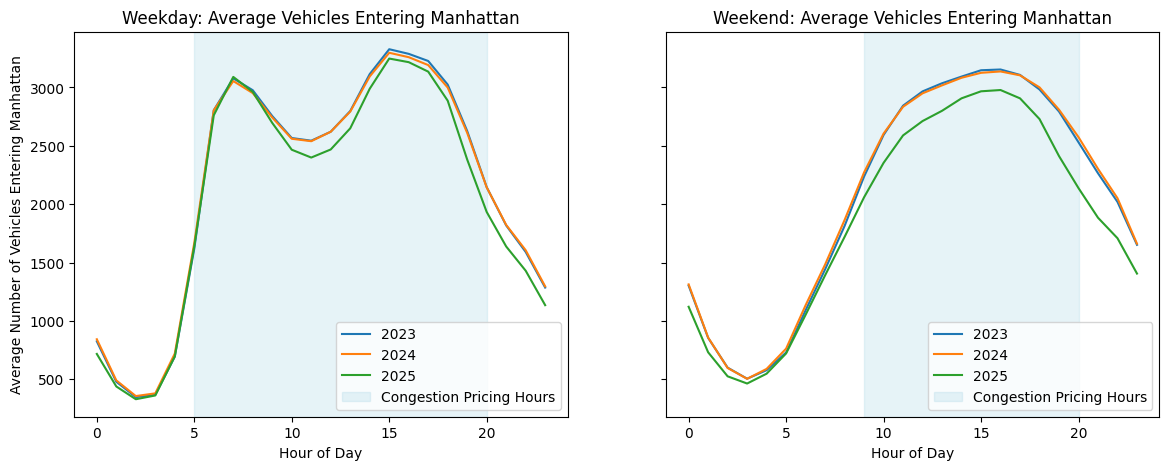

In [44]:
vehicles_entering_manhattan = pd.read_csv("MTA_Bridges_&_Tunnels_Hourly_Traffic_Rates__2010_-_2025_20251101.csv")
vehicles_entering_manhattan["# Vehicles - E-ZPass"] = vehicles_entering_manhattan["# Vehicles - E-ZPass"].str.replace(",", "").astype(int)
vehicles_entering_manhattan["# Vehicles - VToll"] = vehicles_entering_manhattan["# Vehicles - VToll"].str.replace(",", "").astype(int)
vehicles_entering_manhattan["Total"] = vehicles_entering_manhattan["# Vehicles - E-ZPass"] + vehicles_entering_manhattan["# Vehicles - VToll"]


vehicles_entering_manhattan["Date"] = pd.to_datetime(vehicles_entering_manhattan["Date"])
vehicles_entering_manhattan["Weekend"] = vehicles_entering_manhattan["Date"].dt.weekday.apply(lambda x: 1 if x >=5 else 0)
vehicles_entering_manhattan["Year"] = vehicles_entering_manhattan["Date"].dt.year
vehicles_entering_manhattan["Month"] = vehicles_entering_manhattan["Date"].dt.month
vehicles_entering_manhattan["Day"] = vehicles_entering_manhattan["Date"].dt.day

vehicles_entering_manhattan_weekend = vehicles_entering_manhattan[vehicles_entering_manhattan["Weekend"] == 1]
vehicles_entering_manhattan_weekday = vehicles_entering_manhattan[vehicles_entering_manhattan["Weekend"] == 0]


fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# Weekday plot
vehicles_entering_manhattan_weekday.groupby(["Year", "Hour"])["Total"].mean().unstack(level=0).plot(kind = "line", ax=axes[0])
axes[0].axvspan(5, 20, color='lightblue', alpha=0.3, label="Congestion Pricing Hours")
axes[0].set_ylabel("Average Number of Vehicles Entering Manhattan")
axes[0].set_xlabel("Hour of Day")
axes[0].set_title("Weekday: Average Vehicles Entering Manhattan")
axes[0].legend(loc="lower right")

# Weekend plot
vehicles_entering_manhattan_weekend.groupby(["Year", "Hour"])["Total"].mean().unstack(level=0).plot(kind = "line", ax=axes[1])
axes[1].axvspan(9, 20, color='lightblue', alpha=0.3, label="Congestion Pricing Hours")
axes[1].set_ylabel("Average Number of Vehicles Entering Manhattan")
axes[1].set_xlabel("Hour of Day")
axes[1].set_title("Weekend: Average Vehicles Entering Manhattan")
axes[1].legend(loc="lower right")

# Checking number of passengers

Query for ridership 23-24
https://data.ny.gov/api/v3/views/kv7t-n8in/query.json?query=SELECT%20%60transit_timestamp%60%2C%20%60bus_route%60%2C%20sum(%60ridership%60)%0AWHERE%20caseless_starts_with(%60bus_route%60%2C%20%22M%22)%0AGROUP%20BY%20%60transit_timestamp%60%2C%20%60bus_route%60%0AHAVING%0A%20%20%60transit_timestamp%60%0A%20%20%20%20BETWEEN%20%222023-01-01T00%3A00%3A00%22%20%3A%3A%20floating_timestamp%0A%20%20%20%20AND%20%222025-11-02T10%3A20%3A20%22%20%3A%3A%20floating_timestamp

Query for ridership 25
https://data.ny.gov/api/v3/views/gxb3-akrn/query.json?query=SELECT%20%60transit_timestamp%60%2C%20%60bus_route%60%2C%20sum(%60ridership%60)%0AWHERE%20caseless_starts_with(%60bus_route%60%2C%20%22M%22)%0AGROUP%20BY%20%60transit_timestamp%60%2C%20%60bus_route%60

In [22]:
ridership_25 = pd.read_csv("MTA_Bus_Hourly_Ridership__Beginning_2025_20251102.csv")
ridership_23_24 = pd.read_csv("MTA_Bus_Hourly_Ridership__2020-2024_20251102.csv")

ridership_25["sum_ridership"] = ridership_25["sum_ridership"].str.replace(",", "").astype(int)
ridership_23_24["sum_ridership"] = ridership_23_24["sum_ridership"].str.replace(",", "").astype(int)

ridership_25["transit_timestamp"] = pd.to_datetime(ridership_25["transit_timestamp"], format = "%m/%d/%Y %I:%M:%S %p")
ridership_23_24["transit_timestamp"] = pd.to_datetime(ridership_23_24["transit_timestamp"], format = "%m/%d/%Y %I:%M:%S %p")

ridership_25["Month"] = pd.to_datetime(ridership_25["transit_timestamp"]).dt.month
ridership_25["Day"] = pd.to_datetime(ridership_25["transit_timestamp"]).dt.day
ridership_25["Year"] = pd.to_datetime(ridership_25["transit_timestamp"]).dt.year
ridership_25["Hour"] = pd.to_datetime(ridership_25["transit_timestamp"]).dt.hour

ridership_23_24["Month"] = pd.to_datetime(ridership_23_24["transit_timestamp"]).dt.month
ridership_23_24["Day"] = pd.to_datetime(ridership_23_24["transit_timestamp"]).dt.day
ridership_23_24["Year"] = pd.to_datetime(ridership_23_24["transit_timestamp"]).dt.year
ridership_23_24["Hour"] = pd.to_datetime(ridership_23_24["transit_timestamp"]).dt.hour

Text(0, 0.5, 'Average Ridership')

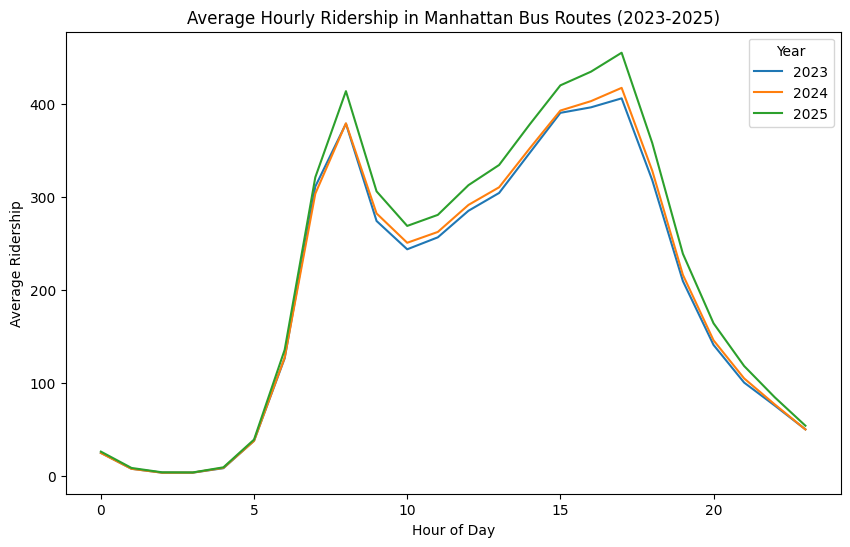

In [23]:
ridership_data = pd.concat([ridership_25, ridership_23_24], axis = 0)
ridership_data.groupby(["Year", "Hour"])["sum_ridership"].mean().unstack(level=0).plot(kind = "line", figsize = (10,6))
plt.title("Average Hourly Ridership in Manhattan Bus Routes (2023-2025)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Ridership")

# Processing data for putting it on a map

## Interpolation Function

The `interpolate_missing_bus_stops()` function processes bus speed data to fill in missing stop segments. 

**What it does:**
1. Identifies gaps in stop sequences (e.g., stop 5 → stop 8, missing 6 and 7)
2. Uses stop reference data to interpolate the missing stops
3. Fills in coordinates and metadata for interpolated stops
4. Inherits speed data from parent segment
5. Returns complete dataset with no gaps

In [24]:
def interpolate_missing_bus_stops(speed_data, stop_data, month_filter=None, save_to_csv=False, output_filename="extended_list.csv"):
    """
    Interpolate missing bus stop segments between timepoints.
    
    This function takes bus speed data and stop data, identifies gaps in stop sequences,
    and fills them by interpolating missing stops using stop location data.
    
    Parameters:
    -----------
    speed_data : pd.DataFrame
        DataFrame containing bus speed data with columns:
        ['year', 'month', 'day_of_week', 'hour_of_day', 'route_id', 'direction_id', 
         'stop_order', 'timepoint_stop_id', 'timepoint_stop_name', 
         'timepoint_stop_latitude', 'timepoint_stop_longitude', 
         'next_timepoint_stop_id', 'next_timepoint_stop_name', 
         'next_timepoint_stop_latitude', 'next_timepoint_stop_longitude', 
         'road_distance', 'average_travel_time', 'average_road_speed']
    
    stop_data : pd.DataFrame
        DataFrame containing stop reference data with columns:
        ['route_id_new', 'stop_order_new', 'direction_id', 'stop_code',
         'stop_id', 'stop_name', 'latitude', 'longitude']
    
    month_filter : int, optional
        Filter data to specific month (1-12). If None, processes all months.
    
    save_to_csv : bool, default False
        Whether to save the result to a CSV file.
    
    output_filename : str, default "extended_list.csv"
        Name of the output CSV file if save_to_csv is True.
    
    Returns:
    --------
    pd.DataFrame
        Extended DataFrame with interpolated stops, including all original columns
        plus filled-in segments for previously missing stops.
    
    Example:
    --------
    >>> extended_data = interpolate_missing_bus_stops(
    ...     speed_data=data_df,
    ...     stop_data=stop_data,
    ...     month_filter=8,
    ...     save_to_csv=True
    ... )
    """
    
    # Step 1: Select relevant columns and sort
    subset = speed_data.loc[:, [
        'year', 'month', 'day_of_week', 'hour_of_day', 'route_id', 'direction_id', 
        'stop_order', 'timepoint_stop_id', 'timepoint_stop_name', 
        'timepoint_stop_latitude', 'timepoint_stop_longitude', 
        'next_timepoint_stop_id', 'next_timepoint_stop_name', 
        'next_timepoint_stop_latitude', 'next_timepoint_stop_longitude', 
        'road_distance', 'average_travel_time', 'average_road_speed'
    ]].copy()
    
    subset = subset.sort_values(['year', 'month', 'day_of_week', 'hour_of_day', 'route_id', 'direction_id', 'stop_order'])
    
    # Step 2: Create key for matching routes and directions
    subset["key"] = subset.loc[:, ['route_id', "direction_id"]].astype(str).agg("-".join, axis=1)
    
    # Step 3: Apply month filter if specified
    if month_filter is not None:
        subset = subset[subset["month"] == month_filter]
    
    # Step 4: Prepare stop data for merging
    stops_subset = stop_data[['route_id_new', 'stop_order_new', 'direction_id', 'stop_code']].copy()
    stops_subset["key"] = stops_subset.loc[:, ['route_id_new', "direction_id"]].astype(str).agg("-".join, axis=1)
    
    # Step 5: Merge to find next stop order
    merged_data = subset.merge(
        stops_subset,
        left_on=["key", "next_timepoint_stop_id"],
        right_on=["key", "stop_code"],
        how="left",
        suffixes=["", "_next_stop"]
    )
    
    merged_data.drop(["route_id_new", "direction_id_next_stop", "stop_code"], axis=1, inplace=True)
    merged_data.rename(columns={"stop_order_new": "next_stop_order"}, inplace=True)
    
    # Step 6: Identify missing segments (gaps > 1 stop)
    merged_data["missing_segments"] = merged_data.apply(
        lambda x: list(range(int(x["stop_order"]), int(x["next_stop_order"]) + 1)) 
        if pd.notna(x["next_stop_order"]) and x["next_stop_order"] - x["stop_order"] > 1 
        else None, 
        axis=1
    )
    
    # Step 7: Separate rows with and without gaps
    original_rows = merged_data[merged_data["missing_segments"].isna()].copy()
    rows_to_expand = merged_data[merged_data["missing_segments"].notna()].copy()
    
    # Step 8: Explode missing segments into individual rows
    expanded_segments = rows_to_expand.explode("missing_segments")
    expanded_segments["target_stop_order"] = expanded_segments["missing_segments"].astype(int)
    expanded_segments["next_stop_order"] = expanded_segments["missing_segments"].astype(int) + 1
    
    # Step 9: Prepare stop data for detailed merging
    stop_data_for_merge = stop_data[['route_id_new', 'direction_id', 'stop_order', 'stop_id', 'stop_name', 'latitude', 'longitude']].copy()
    stop_data_for_merge["stop_order"] = stop_data_for_merge["stop_order"].astype(int)
    
    # Step 10: Merge to get target stop information
    merged_expanded = expanded_segments.merge(
        stop_data_for_merge,
        left_on=['route_id', 'direction_id', 'target_stop_order'],
        right_on=['route_id_new', 'direction_id', 'stop_order'],
        how='left',
        suffixes=['', '_target']
    )
    
    # Step 11: Merge to get next stop information
    merged_expanded = merged_expanded.merge(
        stop_data_for_merge,
        left_on=['route_id', 'direction_id', 'next_stop_order'],
        right_on=['route_id_new', 'direction_id', 'stop_order'],
        how='left',
        suffixes=['', '_next']
    )
    
    # Step 12: Clean up temporary columns
    expanded_segments = expanded_segments.drop(["next_stop_order", "missing_segments"], axis=1)
    original_rows = original_rows.drop(["next_stop_order", "missing_segments"], axis=1)
    
    # Step 13: Select and rename columns for interpolated rows
    interpolated_rows = merged_expanded[[
        'year', 'month', 'day_of_week', 'hour_of_day', 'route_id',
        'direction_id', 'target_stop_order',
        'stop_id', 'stop_name', 'latitude', 'longitude', 
        'stop_id_next', 'stop_name_next',
        'latitude_next', 'longitude_next', 'average_road_speed',
        'key', 'stop_order_next'
    ]].rename(columns={
        'target_stop_order': 'stop_order',
        'stop_id': 'timepoint_stop_id',
        'stop_name': 'timepoint_stop_name',
        'latitude': 'timepoint_stop_latitude',
        'longitude': 'timepoint_stop_longitude',
        'stop_id_next': 'next_timepoint_stop_id',
        'stop_name_next': 'next_timepoint_stop_name',
        'latitude_next': 'next_timepoint_stop_latitude',
        'longitude_next': 'next_timepoint_stop_longitude',
        'stop_order_next': 'next_stop_order'
    })
    
    # Step 14: Add missing columns to interpolated rows
    interpolated_rows['road_distance'] = None
    interpolated_rows['average_travel_time'] = None
    
    # Step 15: Add next_stop_order to original rows
    original_rows["next_stop_order"] = original_rows["stop_order"] + 1
    
    # Step 16: Filter original rows to keep only valid ones
    original_rows_keep = original_rows[~original_rows["next_stop_order"].isna()].drop_duplicates()
    
    # Step 17: Concatenate original and interpolated rows
    result_df = pd.concat([original_rows_keep, interpolated_rows], axis=0)
    
    # Step 18: Remove rows with missing coordinates
    result_df = result_df.dropna(subset=[
        "next_timepoint_stop_latitude",
        "timepoint_stop_latitude",
        "next_timepoint_stop_longitude",
        "timepoint_stop_longitude"
    ])
    
    # Step 19: Save to CSV if requested
    if save_to_csv:
        result_df.to_csv(output_filename, index=False)

    return result_df

## Processing the data for visualization

In [45]:
new_df = interpolate_missing_bus_stops(data_df, stop_data, month_filter=8)

/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_9493/629541519.py:159: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([original_rows_keep, interpolated_rows], axis=0)


In [25]:
visualization_data = data_df[((data_df["year"] == 2024) | \
                             (data_df["year"] == 2025)) &  \
                             (data_df["month"] == 8) & \
                             (data_df["hour_of_day"].isin([2, 8, 14, 20])) \
                             ]

# Process all months and save to CSV
extended_df = interpolate_missing_bus_stops(
    speed_data= visualization_data,
    stop_data=stop_data,
    month_filter=None,  # Process all months (or set to 8 for August only)
    save_to_csv=True,
    output_filename="visualization_24_25.csv"
)

# View the result
extended_df.head()

/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_9493/629541519.py:159: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([original_rows_keep, interpolated_rows], axis=0)


,year,month,day_of_week,hour_of_day,route_id,direction_id,stop_order,timepoint_stop_id,timepoint_stop_name,timepoint_stop_latitude,timepoint_stop_longitude,next_timepoint_stop_id,next_timepoint_stop_name,next_timepoint_stop_latitude,next_timepoint_stop_longitude,road_distance,average_travel_time,average_road_speed,key,next_stop_order
0,2024,8,Friday,2,M10,0,1,403846,8 AV/W 57 ST,40.766740,-73.982683,401245,CENTRAL PK W/W 66 ST,40.772641,-73.978424,0.493,2.433318,12.156231,M10-0,2.0
7,2024,8,Friday,2,M101,0,1,405154,ASTOR PL/COOPER SQ EAST,40.729574,-73.990040,403855,3 AV/E 23 ST,40.739218,-73.982771,0.771,3.187500,14.512941,M101-0,2.0
11,2024,8,Friday,2,M101,0,34,403777,3 AV / E 97 ST,40.785730,-73.948748,401946,3 AV/E 99 ST,40.787906,-73.947273,0.170,0.603324,16.906339,M101-0,35.0
13,2024,8,Friday,2,M101,0,44,402502,E 125 ST/3 AV,40.803935,-73.936221,402512,W 125 ST/AMSTERDAM AV,40.813537,-73.956365,1.239,9.072222,8.194246,M101-0,45.0
30,2024,8,Friday,2,M101,1,73,402854,3 AV/E 23 ST,40.738982,-73.983129,903148,3 AV/ASTOR PL,40.729113,-73.990259,0.777,5.073336,9.189220,M101-1,74.0


# Creating visualization

In [46]:
from folium.plugins import MarkerCluster

def plot_bus_routes(data_df, year=None, month=None, weekday=None, hour = None, route_id=None, marker = None):
    """
    Plot NYC bus routes with color indicating average speed.
    """

    # ---- Filter data ----
    df = data_df.copy()
    if month is not None:
        df = df[df["month"] == month]
    if weekday is not None:
        df = df[df["day_of_week"] == weekday]
    if route_id is not None:
        df = df[df["route_id"] == route_id]
    if hour is not None:
        df = df[df["hour_of_day"] == hour]
    if year is not None:
        df = df[df["year"] == year]

    # ---- Create colors ----
    routes = sorted(df['route_id'].dropna().unique())
    cmap = plt.get_cmap('Paired', len(routes))    
    route_colors = {r: mcolors.to_hex(cmap(i)) for i, r in enumerate(routes)}

    # ---- Compute speed range ----
    speeds = df["average_road_speed"].dropna()
    min_s, max_s = speeds.min(), speeds.max()
    norm = mcolors.Normalize(vmin=min_s, vmax=max_s)
    cmap = plt.get_cmap("RdYlGn")

    # ---- Initialize map ----
    m = folium.Map(location=[40.7831, -73.9712], zoom_start=12, tiles="CartoDB positron")
    marker_cluster = MarkerCluster(name="Stops", disableClusteringAtZoom=10, maxClusterRadius=60).add_to(m)

    # ---- Plot routes ----
    for _, row in df.iterrows():
        speed = row["average_road_speed"]
        
        # Getting the coordinates
        lat1 = row.get("timepoint_stop_latitude")
        lon1 = row.get("timepoint_stop_longitude")
        lat2 = row.get("next_timepoint_stop_latitude")
        lon2 = row.get("next_timepoint_stop_longitude")
        
        line_coords = [[lat1, lon1], [lat2, lon2]]

        color = mcolors.to_hex(cmap(norm(speed)))
        color_route = route_colors.get(row["route_id"])
        
        # creating stop names for markers in loop
        stop_names = [row["timepoint_stop_name"], row["next_timepoint_stop_name"]]

        # ---- add markers if toggled to True ----
        if marker is not None and marker:
            for i in range(2):
                folium.CircleMarker(
                    location = line_coords[i],
                    radius = 7,
                    color= color_route,
                    fill_color = color_route,
                    fill = True,
                    popup=f"Route: {row['route_id']} \n Stop: {stop_names[i]}",
                ).add_to(marker_cluster)

        folium.PolyLine(
            locations = line_coords,
            color = color,
            weight = 3,
            opacity = 0.8,
            popup = f"{row['route_id']} | {speed:.1f} mph"
        ).add_to(m)

    return m


# Examples:
# Plot specific route M4 for January on Monday
m = plot_bus_routes(new_df, year = 2025, weekday = "Tuesday", hour = 14, marker = False)
m